<a href="https://colab.research.google.com/github/Lparedes14/AI-Training-Model-Driving-Recognizition/blob/main/Fitness_Market_Analysis_LA_Fitness_Expansion_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## **Fitness Market Analysis: LA Fitness Expansion Strategy**



# DataPipeline and Workflow

#### MSIS Group 8:  Luis, Thenmani, Claudia, Valentina 

## Step 1: Data Collection (Week 1)

### 1.1 Google Maps LA Fitness Extraction



#### Set the API Key


In [ ]:
import os
from google.colab import userdata

os.environ["GOOGLE_PLACES_API_KEY"] = userdata.get("GOOGLE_PLACES_API_KEY")

In [ ]:
import os
import csv
import time
import requests

API_KEY = os.environ.get("GOOGLE_PLACES_API_KEY")
if not API_KEY:
    raise SystemExit("Set the GOOGLE_PLACES_API_KEY environment variable first.")

SEARCH_URL = "https://places.googleapis.com/v1/places:searchText"
CENSUS_GEOCODER = "https://geocoding.geo.census.gov/geocoder/geographies/coordinates"

CHAINS = {
    "LA Fitness": ["la fitness"],
    "Planet Fitness": ["planet fitness"],
    "24 Hour Fitness": ["24 hour fitness"],
    "Gold's Gym": ["gold's gym", "golds gym"],
    "Orangetheory Fitness": ["orangetheory"],
}

CHAIN_PREFIX = {
    "LA Fitness": "LAF",
    "Planet Fitness": "PLF",
    "24 Hour Fitness": "24H",
    "Gold's Gym": "GLD",
    "Orangetheory Fitness": "OTF",
}

FL_BOUNDS = {"lat_min": 24.4, "lat_max": 31.1, "lon_min": -87.6, "lon_max": -79.9}
GRID_STEP_DEG = 0.6
RADIUS_M = 45000

FIELD_MASK = (
    "places.id,places.displayName,places.formattedAddress,"
    "places.location,places.rating,places.userRatingCount"
)


def build_grid():
    points = []
    lat = FL_BOUNDS["lat_min"]
    while lat <= FL_BOUNDS["lat_max"]:
        lon = FL_BOUNDS["lon_min"]
        while lon <= FL_BOUNDS["lon_max"]:
            points.append((round(lat, 3), round(lon, 3)))
            lon += GRID_STEP_DEG
        lat += GRID_STEP_DEG
    return points


def search_chain_in_cell(query_text, lat, lon):
    headers = {
        "Content-Type": "application/json",
        "X-Goog-Api-Key": API_KEY,
        "X-Goog-FieldMask": FIELD_MASK,
    }
    body = {
        "textQuery": f"{query_text}, Florida",
        "locationBias": {
            "circle": {"center": {"latitude": lat, "longitude": lon}, "radius": RADIUS_M}
        },
        "maxResultCount": 20,
    }
    resp = requests.post(SEARCH_URL, headers=headers, json=body, timeout=30)
    resp.raise_for_status()
    return resp.json().get("places", [])


def get_county(lat, lon):
    if lat is None or lon is None:
        return ""
    params = {
        "x": lon, "y": lat,
        "benchmark": "Public_AR_Current",
        "vintage": "Current_Current",
        "format": "json",
    }
    try:
        resp = requests.get(CENSUS_GEOCODER, params=params, timeout=15)
        resp.raise_for_status()
        counties = resp.json()["result"]["geographies"].get("Counties", [])
        return counties[0]["NAME"] if counties else ""
    except Exception:
        return ""


def collect_chain(chain, match_terms, seen_ids, rows):
    prefix = CHAIN_PREFIX[chain]
    count_for_chain = 0
    for lat, lon in build_grid():
        try:
            places = search_chain_in_cell(chain, lat, lon)
        except requests.HTTPError as e:
            print(f"  ! request failed near ({lat}, {lon}): {e}")
            continue

        for p in places:
            pid = p.get("id")
            if not pid or pid in seen_ids:
                continue

            name = p.get("displayName", {}).get("text", "").lower()
            if not any(term in name for term in match_terms):
                continue

            seen_ids.add(pid)
            loc = p.get("location", {})
            county = get_county(loc.get("latitude"), loc.get("longitude"))
            count_for_chain += 1

            rows.append({
                "LocationID": f"{prefix}-{count_for_chain:04d}",
                "GymChain": chain,
                "LocationName": name,
                "Address": p.get("formattedAddress", ""),
                "CountyName": county,
                "Latitude": loc.get("latitude"),
                "Longitude": loc.get("longitude"),
                "Rating": p.get("rating", ""),
                "ReviewCount": p.get("userRatingCount", ""),
            })
            time.sleep(0.05)

        time.sleep(0.1)


def main():
    seen_ids = set()
    rows = []
    for chain, match_terms in CHAINS.items():
        print(f"Searching: {chain} ...")
        before = len(rows)
        collect_chain(chain, match_terms, seen_ids, rows)
        print(f"  -> {len(rows) - before} locations found")

    out_path = "florida_gym_locations.csv"
    fieldnames = ["LocationID", "GymChain", "CountyName", "Latitude",
                  "Longitude", "Rating", "ReviewCount"]
    with open(out_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(rows)

    print(f"\nDone. Wrote {len(rows)} rows to {out_path}")


main()

Searching: LA Fitness ...
  -> 90 locations found
Searching: Planet Fitness ...
  -> 184 locations found
Searching: 24 Hour Fitness ...
  -> 2 locations found
Searching: Gold's Gym ...
  -> 4 locations found
Searching: Orangetheory Fitness ...
  -> 102 locations found

Done. Wrote 382 rows to florida_gym_locations.csv


### 1.2 Census & Demographic Data

In [ ]:
import requests
import pandas as pd
from io import BytesIO
from zipfile import ZipFile
os.environ["CENSUS_API_KEY"] = userdata.get("CENSUS_API_KEY")
CENSUS_API_KEY = os.environ.get("CENSUS_API_KEY")   # To get API Key free at https://api.census.gov/data/key_signup.html
FL_STATE_FIPS = "12"   # Florida's state code

##### ***2020 Census population (Decennial Census API)***

In [ ]:
def get_2020_population(state_fips="12", api_key=None):
    url = "https://api.census.gov/data/2020/dec/pl"
    params = {"get": "NAME,P1_001N", "for": "county:*", "in": f"state:{state_fips}"}
    if api_key:
        params["key"] = api_key
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    df = df.rename(columns={"P1_001N": "CountyPopulation", "NAME": "CountyNameRaw"})
    df["CountyPopulation"] = df["CountyPopulation"].astype(int)
    df["CountyFIPS"] = df["state"] + df["county"]
    df["CountyName"] = df["CountyNameRaw"].str.replace(" County, Florida", "", regex=False)
    return df[["CountyFIPS", "CountyName", "CountyPopulation"]]

pop_df = get_2020_population(FL_STATE_FIPS, CENSUS_API_KEY)
pop_df.head()

,CountyFIPS,CountyName,CountyPopulation
0,12001,Alachua,278468
1,12003,Baker,28259
2,12005,Bay,175216
3,12007,Bradford,28303
4,12009,Brevard,606612


##### ***ACS 2021 median household income***

In [ ]:
def get_median_income(state_fips="12", api_key=None):
    url = "https://api.census.gov/data/2021/acs/acs5"
    params = {"get": "NAME,B19013_001E", "for": "county:*", "in": f"state:{state_fips}"}
    if api_key:
        params["key"] = api_key
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    df = df.rename(columns={"B19013_001E": "MedianHouseholdIncome"})
    df["MedianHouseholdIncome"] = pd.to_numeric(df["MedianHouseholdIncome"], errors="coerce")
    df["CountyFIPS"] = df["state"] + df["county"]
    return df[["CountyFIPS", "MedianHouseholdIncome"]]

income_df = get_median_income(FL_STATE_FIPS, CENSUS_API_KEY)
income_df.head()

,CountyFIPS,MedianHouseholdIncome
0,12001,53314
1,12003,63860
2,12005,60473
3,12007,48803
4,12009,63632


In this case, We used ACS 5-year estimates (acs5), not 1-year. The Census Bureau only publishes 1-year ACS estimates for counties with 65,000+ people — several small Florida counties (Liberty, Lafayette, Glades, etc.) would be missing entirely if you used acs1. The 5-year file (2017–2021 pooled) is the only one that covers all 67 counties.

##### ***Land area (Gazetteer file)***

The Census/ACS APIs don't return land area, so this comes from a separate Census Gazetteer file, which already has area pre-calculated per county

In [ ]:
GAZETTEER_URL = "https://www2.census.gov/geo/docs/maps-data/data/gazetteer/2020_Gazetteer/2020_Gaz_counties_national.zip"

def get_land_area(state_usps="FL"):
    resp = requests.get(GAZETTEER_URL, timeout=60)
    resp.raise_for_status()
    with ZipFile(BytesIO(resp.content)) as z:
        fname = z.namelist()[0]
        with z.open(fname) as f:
            df = pd.read_csv(f, sep="\t", dtype=str)
    df.columns = [c.strip() for c in df.columns]  # these files have trailing spaces in headers
    df = df[df["USPS"].str.strip() == state_usps].copy()
    df["CountyFIPS"] = df["GEOID"].astype(str)
    df["LandAreaSqMiles"] = df["ALAND_SQMI"].astype(float)
    return df[["CountyFIPS", "LandAreaSqMiles"]]

land_df = get_land_area("FL")
land_df.head()

,CountyFIPS,LandAreaSqMiles
321,12001,875.635
322,12003,585.230
323,12005,758.642
324,12007,293.964
325,12009,1014.971


##### ***Merge everything and compute density***

In [ ]:
county_df = pop_df.merge(income_df, on="CountyFIPS").merge(land_df, on="CountyFIPS")
county_df["PopulationDensity"] = county_df["CountyPopulation"] / county_df["LandAreaSqMiles"]

final_df = (
    county_df[["CountyName", "CountyPopulation", "MedianHouseholdIncome",
               "LandAreaSqMiles", "PopulationDensity"]]
    .sort_values("CountyName")
    .reset_index(drop=True)
)

print(f"Rows: {len(final_df)}")  # should be 67
final_df

Rows: 67


,CountyName,CountyPopulation,MedianHouseholdIncome,LandAreaSqMiles,PopulationDensity
0,Alachua,278468,53314,875.635,318.018352
1,Baker,28259,63860,585.230,48.286998
2,Bay,175216,60473,758.642,230.960058
3,Bradford,28303,48803,293.964,96.280497
4,Brevard,606612,63632,1014.971,597.664367
...,...,...,...,...,...
62,Union,16147,55463,243.555,66.297140
63,Volusia,553543,56786,1101.312,502.621419
64,Wakulla,33764,72941,606.418,55.677767
65,Walton,75305,68111,1038.293,72.527697


Download the file as a CSV:

In [ ]:
final_df.to_csv("florida_county_demographics.csv", index=False)

from google.colab import files
files.download("florida_county_demographics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 1.3 Membership Price Research

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving florida_gym_membership_prices.csv to florida_gym_membership_prices.csv


In [ ]:
price_df = pd.read_csv("florida_gym_membership_prices.csv")
print(f"Rows: {len(price_df)}")
price_df.head()

Rows: 67


,CountyName,MembershipPrice (USD)
0,Alachua County,42
1,Baker County,35
2,Bay County,42
3,Bradford County,35
4,Brevard County,42


## Step 2: Data Integration & Aggregation (Week 2)

##### ***Upload your three source files***

In [ ]:
from google.colab import files
print("Upload: florida_gym_locations.csv, florida_county_demographics.csv, florida_gym_membership_prices.csv")
uploaded = files.upload()

In [ ]:
locations_df = pd.read_csv("florida_gym_locations.csv")
demo_df = pd.read_csv("florida_county_demographics.csv")
price_df = pd.read_csv("florida_gym_membership_prices.csv")

print(locations_df.shape, demo_df.shape, price_df.shape)

(382, 7) (67, 5) (67, 2)


##### ***Fixing county name mismatch***

In [ ]:
def normalize_county(name):
    return (str(name).strip()
            .replace(" County, Florida", "")
            .replace(", Florida", "")
            .replace(" County", "")
            .strip())

locations_df["CountyKey"] = locations_df["CountyName"].apply(normalize_county)
demo_df["CountyKey"] = demo_df["CountyName"].apply(normalize_county)
price_df["CountyKey"] = price_df["CountyName"].apply(normalize_county)

Aggregate gym locations by county

In [ ]:
la_fitness_counts = (
    locations_df[locations_df["GymChain"] == "LA Fitness"]
    .groupby("CountyKey").size().rename("LAFitnessLocations")
)

competitor_counts = (
    locations_df[locations_df["GymChain"] != "LA Fitness"]
    .groupby("CountyKey").size().rename("CompetitorLocations")
)

avg_rating = (
    locations_df.dropna(subset=["Rating"])
    .groupby("CountyKey")["Rating"].mean().rename("AvgGymRating")
)

agg_df = pd.concat([la_fitness_counts, competitor_counts, avg_rating], axis=1).reset_index()
agg_df.head()

,CountyKey,LAFitnessLocations,CompetitorLocations,AvgGymRating
0,Brevard,2.0,9,4.309091
1,Broward,13.0,27,4.417500
2,Clay,1.0,4,4.320000
3,Collier,1.0,4,4.180000
4,Duval,3.0,19,4.422727


Merge into one row per county

In [ ]:
main_df = (
    demo_df[["CountyKey", "CountyName", "CountyPopulation", "MedianHouseholdIncome", "PopulationDensity"]]
    .merge(price_df[["CountyKey", "MembershipPrice (USD)"]], on="CountyKey", how="left")
    .merge(agg_df, on="CountyKey", how="left")
)

print(f"Rows: {len(main_df)}")  # should be 67
main_df.head()

Rows: 67


,CountyKey,CountyName,CountyPopulation,MedianHouseholdIncome,PopulationDensity,MembershipPrice (USD),LAFitnessLocations,CompetitorLocations,AvgGymRating
0,Alachua,Alachua,278468,53314,318.018352,42,NaN,4.0,4.300000
1,Baker,Baker,28259,63860,48.286998,35,NaN,NaN,NaN
2,Bay,Bay,175216,60473,230.960058,42,NaN,3.0,4.633333
3,Bradford,Bradford,28303,48803,96.280497,35,NaN,NaN,NaN
4,Brevard,Brevard,606612,63632,597.664367,42,2.0,9.0,4.309091


##### ***Handle Missing Data***

In [ ]:

main_df["LAFitnessLocations"] = main_df["LAFitnessLocations"].fillna(0).astype(int)
main_df["CompetitorLocations"] = main_df["CompetitorLocations"].fillna(0).astype(int)

main_df["AvgGymRating_Imputed"] = main_df["AvgGymRating"].isna()
statewide_avg_rating = main_df["AvgGymRating"].mean()
main_df["AvgGymRating"] = main_df["AvgGymRating"].fillna(statewide_avg_rating)

print(f"Counties with imputed rating: {main_df['AvgGymRating_Imputed'].sum()}")
main_df.isna().sum()  # should be all zeros now

Counties with imputed rating: 24


,0
CountyKey,0
CountyName,0
CountyPopulation,0
MedianHouseholdIncome,0
PopulationDensity,0
MembershipPrice (USD),0
LAFitnessLocations,0
CompetitorLocations,0
AvgGymRating,0
AvgGymRating_Imputed,0


In [ ]:
main_df = main_df.rename(columns={"MembershipPrice (USD)": "MembershipPrice"})

final_columns = ["CountyName", "MembershipPrice", "CountyPopulation", "LAFitnessLocations",
                  "CompetitorLocations", "MedianHouseholdIncome", "PopulationDensity", "AvgGymRating"]

MainDataset = main_df[final_columns + ["AvgGymRating_Imputed"]].copy()
print(f"Final shape: {MainDataset.shape}")  # (67, 9) — 7 model variables + CountyName + imputation flag

MainDataset.to_csv("MainDataset.csv", index=False)
from google.colab import files
files.download("MainDataset.csv")

MainDataset.head(10)

Final shape: (67, 9)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,CountyName,MembershipPrice,CountyPopulation,LAFitnessLocations,CompetitorLocations,MedianHouseholdIncome,PopulationDensity,AvgGymRating,AvgGymRating_Imputed
0,Alachua,42,278468,0,4,53314,318.018352,4.300000,False
1,Baker,35,28259,0,0,63860,48.286998,4.437581,True
2,Bay,42,175216,0,3,60473,230.960058,4.633333,False
3,Bradford,35,28303,0,0,48803,96.280497,4.437581,True
4,Brevard,42,606612,2,9,63632,597.664367,4.309091,False
5,Broward,58,1944375,13,27,64522,1616.633312,4.417500,False
6,Calhoun,35,13648,0,0,38098,24.056291,4.437581,True
7,Charlotte,42,186847,0,2,57887,274.323576,4.400000,False
8,Citrus,42,153843,0,2,48664,264.372300,4.500000,False
9,Clay,42,218245,1,4,74059,360.967630,4.320000,False


## Step 3: Exploratory Data Analysis (Week 2)

#### Summary Statistics

In [ ]:
numeric_cols = ["MembershipPrice", "CountyPopulation", "LAFitnessLocations",
                 "CompetitorLocations", "MedianHouseholdIncome", "PopulationDensity", "AvgGymRating"]

summary_stats = MainDataset[numeric_cols].agg(["mean", "median", "std", "min", "max"]).T
summary_stats.columns = ["Mean", "Median", "Std Dev", "Min", "Max"]
summary_stats.round(2)

,Mean,Median,Std Dev,Min,Max
MembershipPrice,42.06,42.00,9.09,35.00,90.00
CountyPopulation,321465.48,129752.00,500924.43,7974.00,2701767.00
LAFitnessLocations,1.34,0.00,3.30,0.00,16.00
CompetitorLocations,4.24,2.00,6.70,0.00,29.00
MedianHouseholdIncome,56360.54,56786.00,11801.24,38088.00,88794.00
PopulationDensity,384.49,188.16,574.10,9.54,3504.16
AvgGymRating,4.44,4.44,0.13,4.10,4.80


#### Correlation matrix

In [ ]:
corr_matrix = MainDataset[numeric_cols].corr()

# Correlations against the target
price_corr = corr_matrix["MembershipPrice"].drop("MembershipPrice").sort_values(ascending=False)
print("Correlation with MembershipPrice:")
price_corr.round(3)

Correlation with MembershipPrice:


,MembershipPrice
CountyPopulation,0.785
CompetitorLocations,0.737
LAFitnessLocations,0.707
MedianHouseholdIncome,0.555
PopulationDensity,0.548
AvgGymRating,-0.108


#### Scatter Plots

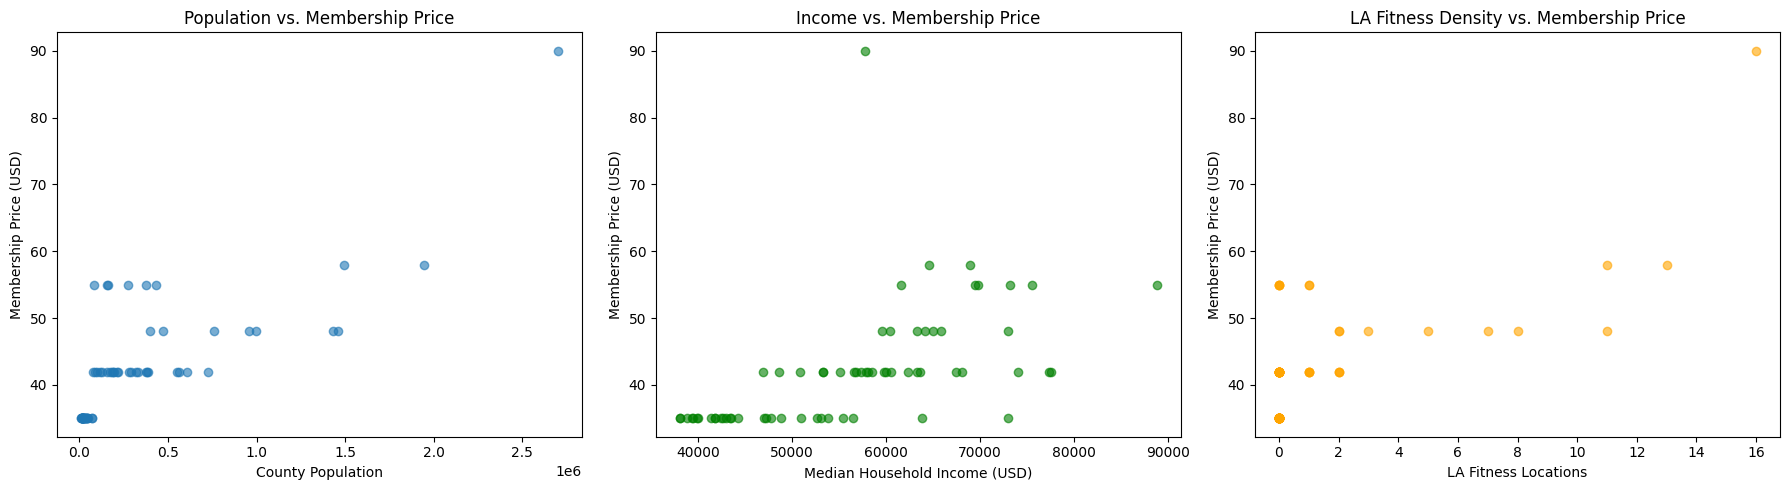

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(MainDataset["CountyPopulation"], MainDataset["MembershipPrice"], alpha=0.6)
axes[0].set_xlabel("County Population")
axes[0].set_ylabel("Membership Price (USD)")
axes[0].set_title("Population vs. Membership Price")

axes[1].scatter(MainDataset["MedianHouseholdIncome"], MainDataset["MembershipPrice"], alpha=0.6, color="green")
axes[1].set_xlabel("Median Household Income (USD)")
axes[1].set_ylabel("Membership Price (USD)")
axes[1].set_title("Income vs. Membership Price")

axes[2].scatter(MainDataset["LAFitnessLocations"], MainDataset["MembershipPrice"], alpha=0.6, color="orange")
axes[2].set_xlabel("LA Fitness Locations")
axes[2].set_ylabel("Membership Price (USD)")
axes[2].set_title("LA Fitness Density vs. Membership Price")

plt.tight_layout()
plt.savefig("scatter_plots.png", dpi=150)
plt.show()

#### Histograms Of MembershipPrice

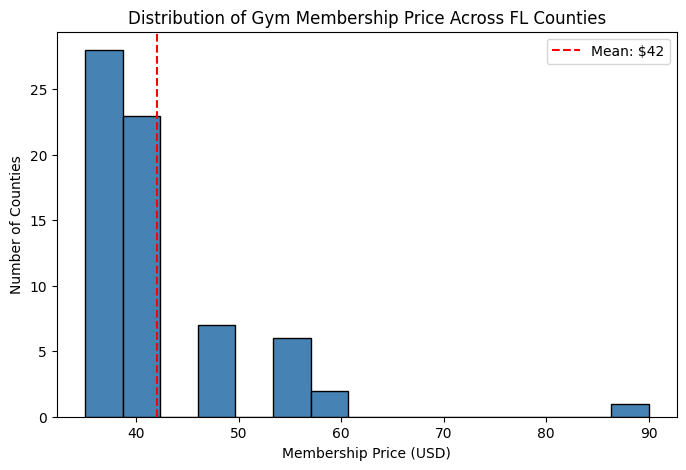

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(MainDataset["MembershipPrice"], bins=15, edgecolor="black", color="steelblue")
plt.xlabel("Membership Price (USD)")
plt.ylabel("Number of Counties")
plt.title("Distribution of Gym Membership Price Across FL Counties")
plt.axvline(MainDataset["MembershipPrice"].mean(), color="red", linestyle="--", label=f"Mean: ${MainDataset['MembershipPrice'].mean():.0f}")
plt.legend()
plt.savefig("price_histogram.png", dpi=150)
plt.show()

#### Heatmap of Corr Matrix

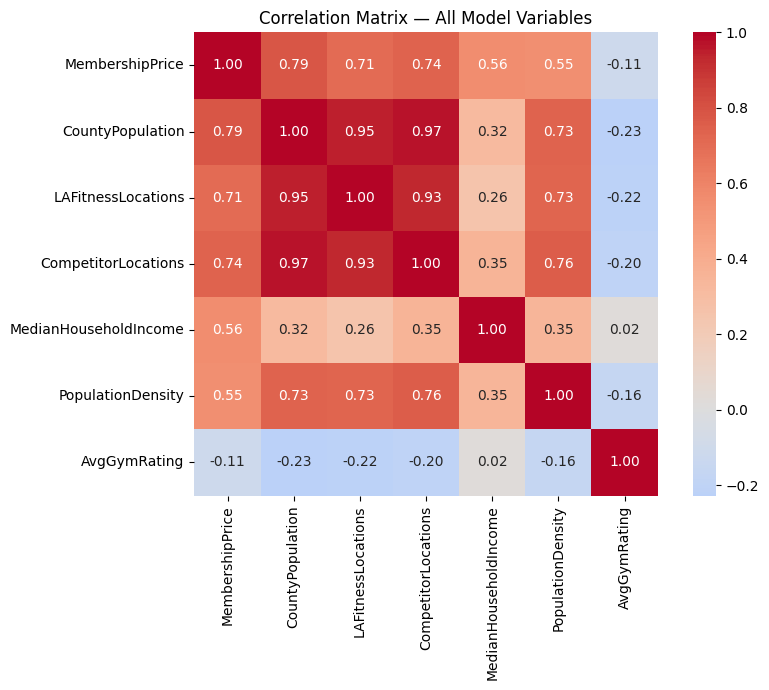

In [ ]:
import seaborn as sns

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix — All Model Variables")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

#### Outliers

In [ ]:
Q1 = MainDataset["MembershipPrice"].quantile(0.25)
Q3 = MainDataset["MembershipPrice"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = MainDataset[
    (MainDataset["MembershipPrice"] < lower_bound) |
    (MainDataset["MembershipPrice"] > upper_bound)
]

print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Outlier counties ({len(outliers)}):")
outliers[["CountyName", "MembershipPrice", "CountyPopulation", "LAFitnessLocations"]]

IQR bounds: [24.50, 52.50]
Outlier counties (9):


,CountyName,MembershipPrice,CountyPopulation,LAFitnessLocations
5,Broward,58,1944375,13
10,Collier,55,375752,1
29,Indian River,55,159788,0
41,Martin,55,158431,0
42,Miami-Dade,90,2701767,16
43,Monroe,55,82874,0
49,Palm Beach,58,1492191,11
55,Sarasota,55,434006,1
57,St. Johns,55,273425,0


**Outliers - Business Implications:**

*   These nine counties are Florida's premium fitness markets, where above-average membership prices reflect affluent demographics and, in several cases, limited large-chain competition
*   Miami-Dade's extreme outlier ($90) likely stems from high-income urban submarkets supporting boutique and luxury gym pricing
*   Notably, six of these counties (Collier, Indian River, Martin, Monroe, Sarasota, St. Johns) have zero or one LA Fitness location despite high prices, suggesting boutique/independent gyms are setting rates in the absence of large-chain competitors.
*   In Summary, these underserved, high-income counties could likely support a new LA Fitness location at premium pricing.


## Step 4: Model Development (Week 2)

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

In [ ]:
predictors = ["CountyPopulation", "LAFitnessLocations", "CompetitorLocations",
              "MedianHouseholdIncome", "PopulationDensity", "AvgGymRating"]
target = "MembershipPrice"

#### OLS Model

In [ ]:
formula = f"{target} ~ " + " + ".join(predictors)
full_model = smf.ols(formula=formula, data=MainDataset).fit()

print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:        MembershipPrice   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     30.62
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           1.57e-16
Time:                        19:23:33   Log-Likelihood:                -195.49
No. Observations:                  67   AIC:                             405.0
Df Residuals:                      60   BIC:                             420.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 6.59

In [ ]:
coef_table = pd.DataFrame({
    "Coefficient": full_model.params,
    "Std Error": full_model.bse,
    "p-value": full_model.pvalues,
    "CI Lower (95%)": full_model.conf_int()[0],
    "CI Upper (95%)": full_model.conf_int()[1],
}).round(4)

print(f"R²: {full_model.rsquared:.4f}   Adjusted R²: {full_model.rsquared_adj:.4f}")
coef_table

R²: 0.7538   Adjusted R²: 0.7292


,Coefficient,Std Error,p-value,CI Lower (95%),CI Upper (95%)
Intercept,6.5922,20.6642,0.7508,-34.7424,47.9267
CountyPopulation,0.0000,0.0000,0.0000,0.0000,0.0000
LAFitnessLocations,-0.2002,0.5709,0.7270,-1.3421,0.9417
CompetitorLocations,-0.7706,0.3678,0.0404,-1.5064,-0.0348
MedianHouseholdIncome,0.0003,0.0001,0.0000,0.0002,0.0004
PopulationDensity,-0.0015,0.0016,0.3584,-0.0046,0.0017
AvgGymRating,3.4554,4.6461,0.4600,-5.8382,12.7489


#### Multicollinearity check (VIF)

In [ ]:
X = sm.add_constant(MainDataset[predictors])
vif_df = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif_df = vif_df[vif_df["Variable"] != "const"].reset_index(drop=True)
vif_df

,Variable,VIF
0,CountyPopulation,20.776945
1,LAFitnessLocations,10.472685
2,CompetitorLocations,17.912376
3,MedianHouseholdIncome,1.238081
4,PopulationDensity,2.431436
5,AvgGymRating,1.068860


#### Residual Diagnosis

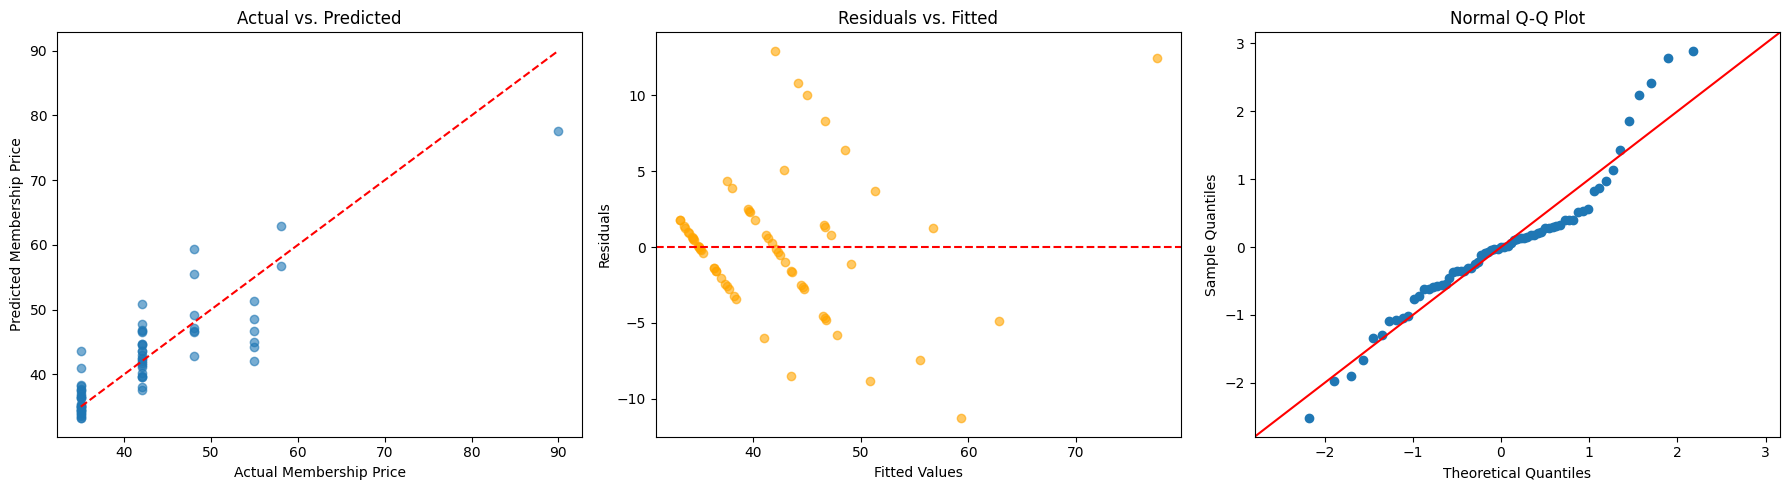

In [ ]:
fitted = full_model.fittedvalues
residuals = full_model.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
axes[0].scatter(MainDataset[target], fitted, alpha=0.6)
axes[0].plot([MainDataset[target].min(), MainDataset[target].max()],
             [MainDataset[target].min(), MainDataset[target].max()], 'r--')
axes[0].set_xlabel("Actual Membership Price")
axes[0].set_ylabel("Predicted Membership Price")
axes[0].set_title("Actual vs. Predicted")

# Residuals vs Fitted
axes[1].scatter(fitted, residuals, alpha=0.6, color="orange")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Fitted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs. Fitted")

# Q-Q plot
sm.qqplot(residuals, line="45", fit=True, ax=axes[2])
axes[2].set_title("Normal Q-Q Plot")

plt.tight_layout()
plt.savefig("residual_diagnostics.png", dpi=150)
plt.show()

#### Normality test

In [ ]:
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
print("  → Residuals are", "normal" if shapiro_p > 0.05 else "NOT normal", "(p > 0.05 = fail to reject normality)")

bp_stat, bp_p, bp_f, bp_f_p = het_breuschpagan(residuals, full_model.model.exog)
print(f"\nBreusch-Pagan: LM statistic={bp_stat:.4f}, p-value={bp_p:.4f}")
print("  → Residuals are", "homoscedastic" if bp_p > 0.05 else "heteroscedastic", "(p > 0.05 = fail to reject homoscedasticity)")

Shapiro-Wilk: statistic=0.9394, p-value=0.0027
  → Residuals are NOT normal (p > 0.05 = fail to reject normality)

Breusch-Pagan: LM statistic=27.7835, p-value=0.0001
  → Residuals are heteroscedastic (p > 0.05 = fail to reject homoscedasticity)


#### Modelo Refinement

In [ ]:
def backward_elimination(data, target, predictors, threshold=0.05):
    current_predictors = predictors.copy()
    while True:
        formula = f"{target} ~ " + " + ".join(current_predictors)
        model = smf.ols(formula=formula, data=data).fit()
        pvals = model.pvalues.drop("Intercept")
        max_p = pvals.max()
        if max_p > threshold and len(current_predictors) > 1:
            drop_var = pvals.idxmax()
            print(f"Dropping '{drop_var}' (p={max_p:.4f})")
            current_predictors.remove(drop_var)
        else:
            break
    return model, current_predictors

parsimonious_model, final_predictors = backward_elimination(MainDataset, target, predictors)
print(f"\nFinal predictors: {final_predictors}")
print(parsimonious_model.summary())

Dropping 'LAFitnessLocations' (p=0.7270)
Dropping 'AvgGymRating' (p=0.4541)
Dropping 'PopulationDensity' (p=0.3179)

Final predictors: ['CountyPopulation', 'CompetitorLocations', 'MedianHouseholdIncome']
                            OLS Regression Results                            
Dep. Variable:        MembershipPrice   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     61.99
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           8.84e-19
Time:                        19:25:50   Log-Likelihood:                -196.41
No. Observations:                  67   AIC:                             400.8
Df Residuals:                      63   BIC:                             409.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
      

#### Compare Full Model vs Parsimonious Model

In [ ]:
comparison = pd.DataFrame({
    "Full Model": [full_model.rsquared, full_model.rsquared_adj, full_model.aic, full_model.bic, len(predictors)],
    "Parsimonious Model": [parsimonious_model.rsquared, parsimonious_model.rsquared_adj,
                            parsimonious_model.aic, parsimonious_model.bic, len(final_predictors)],
}, index=["R²", "Adjusted R²", "AIC", "BIC", "# Predictors"])

comparison.round(4)


,Full Model,Parsimonious Model
R²,0.7538,0.7470
Adjusted R²,0.7292,0.7349
AIC,404.9807,400.8254
BIC,420.4135,409.6442
# Predictors,6.0000,3.0000


#### Output

In [ ]:
with open("regression_summary.txt", "w") as f:
    f.write("FULL MODEL\n" + "="*70 + "\n")
    f.write(str(full_model.summary()))
    f.write("\n\nPARSIMONIOUS MODEL\n" + "="*70 + "\n")
    f.write(str(parsimonious_model.summary()))

from google.colab import files
files.download("regression_summary.txt")
files.download("residual_diagnostics.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 5: Predictions & Business Insights (Week 2)

In [ ]:


# Scenario A: assignment specifies population/LA Fitness/competitors only —
# borrow income/density/rating from real FL counties in that population range
rural_comps = MainDataset[(MainDataset["CountyPopulation"] > 30000) & (MainDataset["CountyPopulation"] < 70000)]
scenario_A = pd.DataFrame([{
    "CountyPopulation": 50000,
    "LAFitnessLocations": 2,
    "CompetitorLocations": 1,
    "MedianHouseholdIncome": rural_comps["MedianHouseholdIncome"].mean(),
    "PopulationDensity": rural_comps["PopulationDensity"].mean(),
    "AvgGymRating": MainDataset["AvgGymRating"].mean(),
}])

# Scenario B: assignment gives Miami-Dade-like numbers — use Miami-Dade's
# actual income/density/rating, override population/competition as specified
miami_actual = MainDataset[MainDataset["CountyName"] == "Miami-Dade"].iloc[0]
scenario_B = pd.DataFrame([{
    "CountyPopulation": 2_600_000,
    "LAFitnessLocations": 15,
    "CompetitorLocations": 30,
    "MedianHouseholdIncome": miami_actual["MedianHouseholdIncome"],
    "PopulationDensity": miami_actual["PopulationDensity"],
    "AvgGymRating": miami_actual["AvgGymRating"],
}])

# Scenario C: user-defined target market — St. Johns flagged in Step 3 as
# affluent with zero LA Fitness presence; model what happens if LA Fitness enters
stjohns_actual = MainDataset[MainDataset["CountyName"] == "St. Johns"].iloc[0]
scenario_C = pd.DataFrame([{
    "CountyPopulation": stjohns_actual["CountyPopulation"],
    "LAFitnessLocations": 1,  # hypothetical: first LA Fitness enters this market
    "CompetitorLocations": stjohns_actual["CompetitorLocations"],
    "MedianHouseholdIncome": stjohns_actual["MedianHouseholdIncome"],
    "PopulationDensity": stjohns_actual["PopulationDensity"],
    "AvgGymRating": stjohns_actual["AvgGymRating"],
}])

scenarios = pd.concat([scenario_A, scenario_B, scenario_C], ignore_index=True)
scenarios.index = ["A: Rural / Low Competition", "B: Miami-Dade / High Competition", "C: St. Johns / Untapped Market"]
scenarios

,CountyPopulation,LAFitnessLocations,CompetitorLocations,MedianHouseholdIncome,PopulationDensity,AvgGymRating
A: Rural / Low Competition,50000,2,1,46980.333333,57.796364,4.437581
B: Miami-Dade / High Competition,2600000,15,30,57815.000000,1422.054483,4.340000
C: St. Johns / Untapped Market,273425,1,4,88794.000000,455.219731,4.650000


#### Predict with 95% confidence intervals

In [ ]:
final_model = parsimonious_model  # switch to full_model if you prefer that specification

pred = final_model.get_prediction(scenarios)
pred_summary = pred.summary_frame(alpha=0.05)
pred_summary.index = scenarios.index

results = pred_summary[["mean", "mean_ci_lower", "mean_ci_upper", "obs_ci_lower", "obs_ci_upper"]].round(2)
results.columns = ["Predicted Price", "CI Lower (avg)", "CI Upper (avg)", "PI Lower (single county)", "PI Upper (single county)"]
results

,Predicted Price,CI Lower (avg),CI Upper (avg),PI Lower (single county),PI Upper (single county)
A: Rural / Low Competition,35.82,34.28,37.37,26.34,45.30
B: Miami-Dade / High Competition,73.27,67.25,79.29,62.15,84.39
C: St. Johns / Untapped Market,50.53,46.94,54.12,40.51,60.55


#### Which factors matter most

In [ ]:
from scipy.stats import zscore
import statsmodels.formula.api as smf

std_data = MainDataset.copy()
for col in final_predictors:
    std_data[col] = zscore(std_data[col])
std_data[target] = zscore(std_data[target])

std_model = smf.ols(formula=f"{target} ~ " + " + ".join(final_predictors), data=std_data).fit()
std_coefs = std_model.params.drop("Intercept").sort_values(key=abs, ascending=False)

print("Standardized coefficients — relative strength of influence on price:")
std_coefs.round(3)

Standardized coefficients — relative strength of influence on price:


,0
CountyPopulation,1.286
CompetitorLocations,-0.641
MedianHouseholdIncome,0.376


**Which factors most strongly influence membership pricing?**



*   Based on the standardized coefficients, county population is the dominant driver of membership price (β = 1.286), followed by median household income (β = 0.376), meaning larger and wealthier markets command meaningfully higher prices.
*   Competitor locations has a smaller but negative effect (β = -0.641), showing that pricing power weakens somewhat as more competing gyms enter a market.
*  Together these results suggest membership pricing in Florida is set primarily by market size and affluence, with competitive density acting as a moderating rather than dominant force.






**How does competition affect price?**

*   The standardized coefficient for CompetitorLocations is negative (-0.641), indicating that as the number of competing fitness chains in a county rises, average membership price tends to fall
*   However, since population and income have larger positive effects, a county can still support high prices despite heavy competition if it's large and affluent enough



#### Top 5 expansion counties, model-driven

In [ ]:
MainDataset["PredictedPrice"] = final_model.predict(MainDataset[final_predictors])

# Opportunity = price the market will bear × size of that market, discounted
# by how much LA Fitness has already saturated it (+1 avoids divide-by-zero)
MainDataset["ExpansionScore"] = (
    MainDataset["PredictedPrice"] * MainDataset["CountyPopulation"] / (MainDataset["LAFitnessLocations"] + 1)
)

top5 = MainDataset.sort_values("ExpansionScore", ascending=False).head(5)
top5[["CountyName", "PredictedPrice", "CountyPopulation", "LAFitnessLocations", "CompetitorLocations", "ExpansionScore"]].round(2)

,CountyName,PredictedPrice,CountyPopulation,LAFitnessLocations,CompetitorLocations,ExpansionScore
50,Pasco,45.77,561891,0,7,25717758.70
52,Polk,50.45,725046,1,5,18290104.93
33,Lake,43.91,383956,0,5,16860902.06
40,Marion,41.93,375908,0,4,15762196.68
57,St. Johns,50.53,273425,0,4,13816767.59


#### Output

In [ ]:
results.to_csv("scenario_predictions.csv")
top5.to_csv("top5_expansion_counties.csv", index=False)

from google.colab import files
files.download("scenario_predictions.csv")
files.download("top5_expansion_counties.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Business recommendations:**
**Top 5 counties for LA Fitness expansion (ranked by market potential)**


*   Based on the ExpansionScore model, Pasco, Polk, Lake, Marion, and St. Johns counties represent the strongest expansion opportunities, combining sizable populations, predicted membership prices in the 42 to 50 dollars, and little to no existing LA Fitness presence.


**What drives membership pricing**


*   County population is the strongest driver of achievable price (β = 1.29), followed by median household income (β = 0.38), while competitor presence has a smaller negative effect (β = -0.64) — meaning the size and wealth of a market matter more to pricing power than how many competitors are already there.
